# Grokking in two minutes — a runnable demo

This notebook trains a small one-layer transformer until it **groks** modular addition, then reverse-engineers the closed-form *clock* circuit it learned — the whole story of the project in a couple of minutes on a laptop GPU (a few minutes on CPU).

The full study — progress measures, ablations, cross-seed universality, and scaling in `p` — is in the [README](../README.md) and the [technical report](../paper/paper.pdf).

In [1]:
%matplotlib inline
import sys, pathlib
here = pathlib.Path.cwd()
repo = here if (here / 'src').exists() else here.parent
sys.path.insert(0, str(repo / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt

from grok import Config
from grok.train import train
from grok.data import make_dataset
from grok.analysis import accuracy, all_logits, model_at
from grok.fourier import (make_fourier_basis, power_by_frequency, gini,
                          key_frequencies, filter_frequencies)
from grok.circuit import decision_function, fit_cosines, accuracy_from_f

print('ready — torch', torch.__version__, '| cuda', torch.cuda.is_available())

ready — torch 2.11.0+cu128 | cuda True


## 1. Train a small model until it groks

On a small prime with enough data, grokking happens in a few thousand steps: train accuracy shoots to 100% almost immediately, while test accuracy sits at chance and then suddenly generalises.

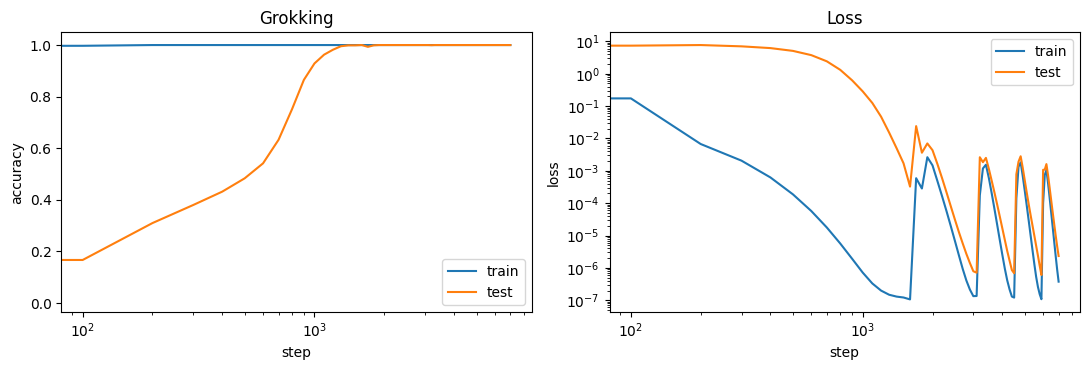

final test accuracy: 1.000


In [2]:
cfg = Config(p=59, train_frac=0.5, epochs=7000, eval_every=100, n_checkpoints=2, seed=0)
res = train(cfg, verbose=False)
h = res.history.as_arrays()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(h['steps'], h['train_acc'], label='train')
ax[0].plot(h['steps'], h['test_acc'], label='test')
ax[0].set(xscale='log', xlabel='step', ylabel='accuracy', title='Grokking')
ax[0].legend()
ax[1].plot(h['steps'], h['train_loss'], label='train')
ax[1].plot(h['steps'], h['test_loss'], label='test')
ax[1].set(xscale='log', yscale='log', xlabel='step', ylabel='loss', title='Loss')
ax[1].legend()
plt.tight_layout(); plt.show()
print(f'final test accuracy: {h["test_acc"][-1]:.3f}')

## 2. The grokked embedding is sparse in Fourier space

The task lives on the cyclic group $\mathbb{Z}_p$, so we look at the embedding in the discrete Fourier basis. After grokking, almost all its power sits on just a handful of frequencies.

key frequencies: [7, 24, 27]  (carry 92.8% of the embedding power)
Fourier sparsity (Gini): 0.858   (0 = uniform, 1 = one spike)


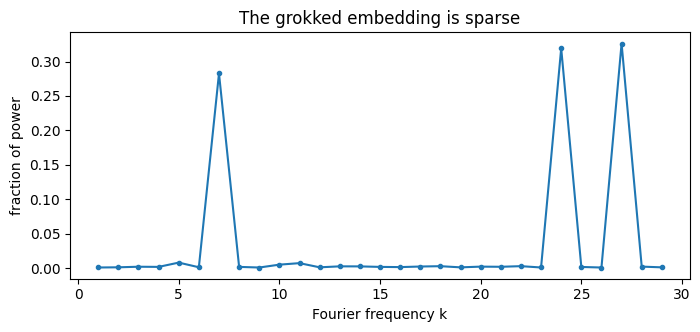

In [3]:
p = cfg.p
F, _ = make_fourier_basis(p)
W_E = res.model.W_E.detach().cpu()[:p]
power = power_by_frequency(W_E, F)
keys, share = key_frequencies(power, cover=0.9)

print(f'key frequencies: {keys}  (carry {share:.1%} of the embedding power)')
print(f'Fourier sparsity (Gini): {gini(power[1:]):.3f}   (0 = uniform, 1 = one spike)')

plt.figure(figsize=(8, 3.2))
plt.plot(range(1, (p + 1) // 2), (power[1:] / power.sum()).numpy(), marker='o', ms=3)
plt.xlabel('Fourier frequency k'); plt.ylabel('fraction of power')
plt.title('The grokked embedding is sparse'); plt.show()

## 3. The circuit is a closed-form sum of cosines

The network's decision function — its logit as a function of $d = (a+b-c)$ — turns out to be a sum of cosines at exactly those key frequencies, peaking at $d = 0$ (i.e. $c = a+b$). Trained only on examples, the transformer has become a formula.

cosine-fit R^2 = 1.0000   |   peaks at d = 0 (clock predicts 0)   |   formula-only accuracy = 100.0%


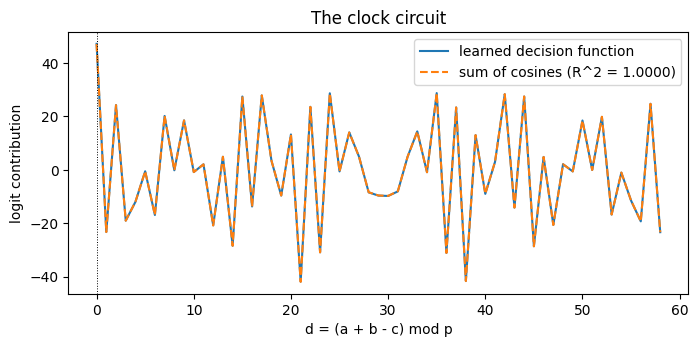

In [4]:
data = make_dataset(cfg, 'cpu')
model = model_at(cfg, res.model.state_dict())
L = all_logits(model, data.all_x, center=True)
f, share_f = decision_function(L)
r2, amps, fhat = fit_cosines(f, keys)
acc, argmax_d = accuracy_from_f(f)

print(f'cosine-fit R^2 = {r2:.4f}   |   peaks at d = {argmax_d} (clock predicts 0)   |   formula-only accuracy = {acc:.1%}')

d = np.arange(p)
plt.figure(figsize=(8, 3.4))
plt.plot(d, f.numpy(), label='learned decision function')
plt.plot(d, fhat.numpy(), '--', label=f'sum of cosines (R^2 = {r2:.4f})')
plt.axvline(0, color='k', lw=0.7, ls=':')
plt.xlabel('d = (a + b - c) mod p'); plt.ylabel('logit contribution')
plt.title('The clock circuit'); plt.legend(); plt.show()

## 4. Causal check — those frequencies *are* the computation

Finally, edit the embedding in Fourier space and re-run the untouched network: keep only the key frequencies and it still solves the task (sufficient); remove them and it collapses to chance (necessary).

In [5]:
def acc_with(keep=None, remove=None):
    sd = {k: v.detach().cpu().clone() for k, v in res.model.state_dict().items()}
    sd['W_E'][:p] = filter_frequencies(sd['W_E'][:p], F, keep=keep, remove=remove).to(sd['W_E'].dtype)
    return accuracy(model_at(cfg, sd), data.all_x, data.all_y)

print(f'full model:          {accuracy(model, data.all_x, data.all_y):.1%}')
print(f'keep only key freqs: {acc_with(keep=keys):.1%}   (sufficient)')
print(f'remove key freqs:    {acc_with(remove=keys):.1%}   (necessary — chance is {1 / p:.1%})')

full model:          100.0%
keep only key freqs: 100.0%   (sufficient)
remove key freqs:    1.7%   (necessary — chance is 1.7%)


That's the whole project in miniature: **grok → sparse frequencies → closed-form clock → causally verified.** The full write-up adds progress measures (grokking is gradual, not sudden), ablations (weight decay is required), cross-seed universality, and how the circuit scales with the modulus — see the [README](../README.md) and [paper](../paper/paper.pdf).